# Loan Default Prediction - Modelling
## Objective
Building and evaluating supervised machine learning models to predict loan default.
This notebook covers data preprocessing, feature engineering, model training,
hyperparameter tuning, and performance evaluation.

Models compared:
- Logistic Regression (baseline)
- Random Forest
- XGBoost

Evaluation metrics:
- AUC-ROC: measures how well the model separates defaulters from non-defaulters
- PR-AUC: precision-recall AUC, more informative than ROC-AUC under heavy class imbalance
- Brier Score: measures probability calibration — how accurate the predicted probabilities are

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, brier_score_loss,
                             average_precision_score, roc_curve,
                             precision_recall_curve)
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/drive/MyDrive/application_train.csv')
print(f"Data loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

Data loaded: 307,511 rows, 122 columns


## 1. Preprocessing
### 1.1 Drop High Missing Columns
Dropping 49 columns with >40% missing values as identified in EDA.
EXT_SOURCE_1 is retained despite 56% missingness due to its known
predictive power in credit risk modelling.

In [5]:
# Drop columns with >40% missing except EXT_SOURCE_1
missing_pct = df.isnull().sum() / len(df) * 100
cols_to_drop = missing_pct[(missing_pct > 40) & (missing_pct.index != 'EXT_SOURCE_1')].index.tolist()
df = df.drop(columns=cols_to_drop)

print(f"Columns dropped: {len(cols_to_drop)}")
print(f"Remaining shape: {df.shape}")

Columns dropped: 48
Remaining shape: (307511, 74)


### 1.2 Imputation
Numerical columns imputed with median, categorical columns with mode
except OCCUPATION_TYPE which is imputed with 'Unknown'.

In [6]:
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Impute numerical with median
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Impute categorical
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        if col == 'OCCUPATION_TYPE':
            df[col] = df[col].fillna('Unknown')
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

print(f"Remaining missing values: {df.isnull().sum().sum()}")
print(f"Shape: {df.shape}")

Remaining missing values: 0
Shape: (307511, 74)


### 1.3 Feature Engineering
Creating new features to capture relationships not explicit in the raw data.
Key features created:
- LOG_INCOME: log transformation of income to address right skew and outliers
- CREDIT_INCOME_RATIO: credit amount relative to income — measures affordability
- ANNUITY_INCOME_RATIO: monthly repayment burden relative to income
- CREDIT_TERM: implicit loan duration
- AGE_YEARS: applicant age in years
- YEARS_EMPLOYED: years in current employment

In [7]:
# Log transform income
df['LOG_INCOME'] = np.log1p(df['AMT_INCOME_TOTAL'])

# Credit to income ratio
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

# Annuity to income ratio
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

# Credit term
df['CREDIT_TERM'] = df['AMT_ANNUITY'] / df['AMT_CREDIT']

# Age in years
df['AGE_YEARS'] = df['DAYS_BIRTH'] / -365

# Fix DAYS_EMPLOYED anomaly (365243 is a placeholder for unemployed)
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].fillna(df['DAYS_EMPLOYED'].median())
df['YEARS_EMPLOYED'] = df['DAYS_EMPLOYED'] / -365

print("Feature engineering complete")
print(f"New shape: {df.shape}")
print(df[['LOG_INCOME', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO',
          'CREDIT_TERM', 'AGE_YEARS', 'YEARS_EMPLOYED']].describe())

Feature engineering complete
New shape: (307511, 80)
          LOG_INCOME  CREDIT_INCOME_RATIO  ANNUITY_INCOME_RATIO  \
count  307511.000000        307511.000000         307511.000000   
mean       11.909245             3.957570              0.180929   
std         0.488906             2.689728              0.094573   
min        10.152338             0.004808              0.000224   
25%        11.630717             2.018667              0.114782   
50%        11.899215             3.265067              0.162833   
75%        12.218500             5.159880              0.229067   
max        18.577685            84.736842              1.875965   

         CREDIT_TERM      AGE_YEARS  YEARS_EMPLOYED  
count  307511.000000  307511.000000   307511.000000  
mean        0.053695      43.936973        6.168784  
std         0.022482      11.956133        5.852585  
min         0.016790      20.517808       -0.000000  
25%         0.036900      34.008219        2.556164  
50%         0.05000

### 1.4 Encoding Categorical Variables
Label encoding applied to categorical columns for compatibility with
tree-based models. Binary categorical variables are encoded as 0/1.

In [8]:
# Label encode categorical columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Categorical encoding complete")
print(f"Shape: {df.shape}")

Categorical encoding complete
Shape: (307511, 80)


### 1.5 Train/Test Split
80/20 train/test split with stratification to preserve class balance
in both sets.

In [9]:
# Define features and target
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Default rate in train: {y_train.mean():.3f}")
print(f"Default rate in test: {y_test.mean():.3f}")

Training set: (246008, 78)
Test set: (61503, 78)
Default rate in train: 0.081
Default rate in test: 0.081


## 2. Model Training
Three models are trained and compared:
- Logistic Regression as a simple interpretable baseline
- Random Forest as an ensemble model
- XGBoost as a gradient boosting model

Class weighting is applied to all models to address the 8.1% default
rate imbalance identified in EDA.

In [10]:
# Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
print("Done")

# Random Forest
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print("Done")

# XGBoost
print("Training XGBoost...")
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(scale_pos_weight=scale_pos_weight,
                     random_state=42, n_jobs=-1, eval_metric='auc')
xgb.fit(X_train, y_train)
print("Done")

Training Logistic Regression...
Done
Training Random Forest...
Done
Training XGBoost...
Done


## 3. Model Evaluation
Evaluating all three models using AUC-ROC, PR-AUC, and Brier Score.
- AUC-ROC: measures separability between classes
- PR-AUC: more informative than ROC-AUC under class imbalance
- Brier Score: measures probability calibration (lower is better)

In [11]:
# Evaluate all models
models = {'Logistic Regression': lr, 'Random Forest': rf, 'XGBoost': xgb}
results = []

for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    auc_roc = roc_auc_score(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)
    brier = brier_score_loss(y_test, y_pred_proba)

    results.append({
        'Model': name,
        'AUC-ROC': round(auc_roc, 4),
        'PR-AUC': round(pr_auc, 4),
        'Brier Score': round(brier, 4)
    })
    print(f"{name}: AUC-ROC={auc_roc:.4f}, PR-AUC={pr_auc:.4f}, Brier={brier:.4f}")

results_df = pd.DataFrame(results)
print("\n", results_df)

Logistic Regression: AUC-ROC=0.6262, PR-AUC=0.1233, Brier=0.2298
Random Forest: AUC-ROC=0.7317, PR-AUC=0.2091, Brier=0.0693
XGBoost: AUC-ROC=0.7573, PR-AUC=0.2452, Brier=0.1731

                  Model  AUC-ROC  PR-AUC  Brier Score
0  Logistic Regression   0.6262  0.1233       0.2298
1        Random Forest   0.7317  0.2091       0.0693
2              XGBoost   0.7573  0.2452       0.1731


### Results Interpretation

**AUC-ROC** — XGBoost achieves the best discrimination (0.757), meaning it
correctly ranks a random defaulter above a random non-defaulter 75.7% of the
time. All models significantly outperform a random classifier (0.5).

**PR-AUC** — Scores appear low but must be interpreted relative to the baseline
of 0.081 (the default rate). XGBoost at 0.245 is approximately 3x better than
random, which is meaningful given the severe class imbalance.

**Brier Score** — Random Forest achieves the best probability calibration (0.069),
suggesting its predicted probabilities are the most accurate in absolute terms.
XGBoost has stronger discriminative power but slightly less well calibrated
probabilities.

**Key finding** — XGBoost is the best model overall for identifying defaulters,
but Random Forest produces better calibrated probability estimates. In a real
credit risk setting, both properties matter — discrimination for ranking applicants
and calibration for setting accurate risk thresholds.

### 3.1 ROC Curves

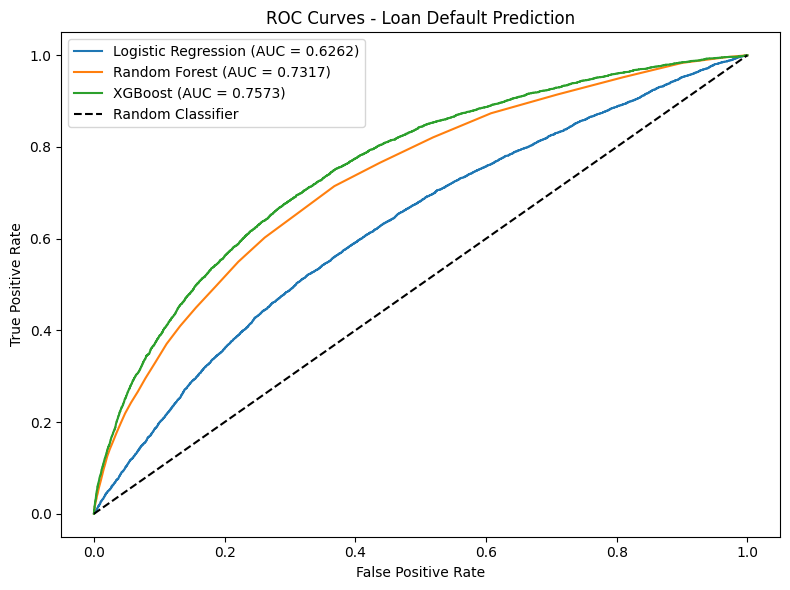

In [12]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Loan Default Prediction')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curves.png')
plt.show()

### 3.2 Precision-Recall Curves

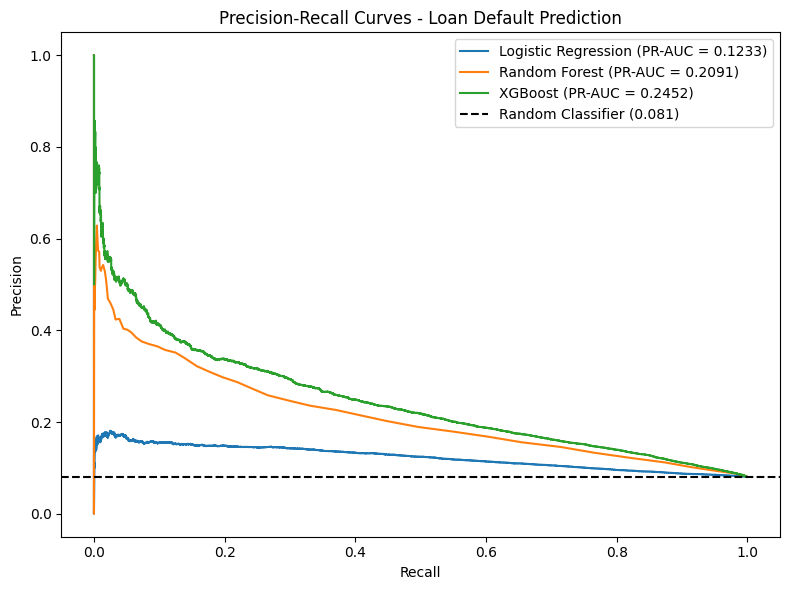

In [13]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)
    plt.plot(recall, precision, label=f'{name} (PR-AUC = {pr_auc:.4f})')

plt.axhline(y=0.081, color='k', linestyle='--', label='Random Classifier (0.081)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - Loan Default Prediction')
plt.legend()
plt.tight_layout()
plt.savefig('precision_recall_curves.png')
plt.show()

### Curve Interpretation

**ROC Curves:** XGBoost (green) dominates throughout, consistently achieving
a higher true positive rate for any given false positive rate. All three models
significantly outperform the random classifier baseline, with XGBoost and Random
Forest showing particularly strong performance at low false positive rates —
important in credit risk where you want to catch defaults without flagging too
many safe borrowers.

**Precision-Recall Curves:** The steep initial drop in precision as recall
increases is expected given the 8.1% class imbalance. XGBoost maintains the
highest precision across most recall thresholds, confirming it as the strongest
model. All models remain above the random classifier baseline (0.081) across
the full recall range, demonstrating genuine predictive power.

## 4. Hyperparameter Tuning
RandomizedSearchCV applied to XGBoost to optimise model performance.
Tuning is focused on the best performing model identified in section 3.
AUC-ROC is used as the scoring metric for hyperparameter selection.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

# Randomized search
xgb_tuned = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc'
)

search = RandomizedSearchCV(
    xgb_tuned,
    param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print(f"Best parameters: {search.best_params_}")
print(f"Best CV AUC-ROC: {search.best_score_:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
